In [13]:
#libraries 
#Tokenization 
import nltk 
from nltk.tokenize import sent_tokenize, word_tokenize 
#Stopwords 
from nltk.corpus import stopwords
#data frame and series manipulation 
import pandas as pd 
#plot 
import matplotlib.pyplot as plt
#Vector space model 
from sklearn.feature_extraction.text import TfidfVectorizer 
#string manipulation and identifier
import string

In [3]:
#Define article 
article = """
The weather has always been a quiet storyteller, shaping the rhythm of daily life in ways people often overlook. From the soft whisper of morning rain to the blazing intensity of midday heat, each shift in the sky carries its own message. In tropical regions, the air feels heavy, almost like it’s holding secrets, before sudden rain pours down and refreshes the earth. Meanwhile, in colder climates, the biting wind reminds people of nature’s raw power, demanding preparation and respect.

Weather is more than just temperature or rain; it influences emotions, decisions, and even productivity. A bright sunny day often lifts spirits and encourages outdoor activity, while gloomy, overcast skies can slow things down, making everything feel a little heavier. Farmers depend on seasonal patterns to grow crops, travelers plan journeys based on forecasts, and cities adjust their pace depending on whether the skies are clear or stormy.

In recent years, however, weather patterns have become increasingly unpredictable. Sudden storms, prolonged heatwaves, and unexpected rainfall are becoming more common, raising questions about long-term environmental changes. This unpredictability challenges not only individuals but entire systems, from agriculture to urban planning.

Despite all this, there is something timeless about weather. It remains one of the few forces that humans cannot fully control. Instead, people adapt, observe, and learn to live alongside it. In a fast-moving world filled with technology and constant noise, the weather quietly reminds us to pause, look up, and stay connected to the natural world.

"""

In [8]:
#Text preprocessing 
#Extract into sentence 
sent_token = sent_tokenize(article)
print(sent_token)

#Extract into word token
token = word_tokenize(article)
print(token)

['\nThe weather has always been a quiet storyteller, shaping the rhythm of daily life in ways people often overlook.', 'From the soft whisper of morning rain to the blazing intensity of midday heat, each shift in the sky carries its own message.', 'In tropical regions, the air feels heavy, almost like it’s holding secrets, before sudden rain pours down and refreshes the earth.', 'Meanwhile, in colder climates, the biting wind reminds people of nature’s raw power, demanding preparation and respect.', 'Weather is more than just temperature or rain; it influences emotions, decisions, and even productivity.', 'A bright sunny day often lifts spirits and encourages outdoor activity, while gloomy, overcast skies can slow things down, making everything feel a little heavier.', 'Farmers depend on seasonal patterns to grow crops, travelers plan journeys based on forecasts, and cities adjust their pace depending on whether the skies are clear or stormy.', 'In recent years, however, weather patter

In [25]:
#with stopword and without stopwords 
stop_word = set(stopwords.words('english'))
filtered_token = [word for word in token if word not in stop_word and word not in string.punctuation]
sentence2 = " ".join(filtered_token)
sent_token2 = sent_tokenize(sentence2)

print("original :", token)
print("filtered:", filtered_token)
print(sent_token2)

original : ['The', 'weather', 'has', 'always', 'been', 'a', 'quiet', 'storyteller', ',', 'shaping', 'the', 'rhythm', 'of', 'daily', 'life', 'in', 'ways', 'people', 'often', 'overlook', '.', 'From', 'the', 'soft', 'whisper', 'of', 'morning', 'rain', 'to', 'the', 'blazing', 'intensity', 'of', 'midday', 'heat', ',', 'each', 'shift', 'in', 'the', 'sky', 'carries', 'its', 'own', 'message', '.', 'In', 'tropical', 'regions', ',', 'the', 'air', 'feels', 'heavy', ',', 'almost', 'like', 'it', '’', 's', 'holding', 'secrets', ',', 'before', 'sudden', 'rain', 'pours', 'down', 'and', 'refreshes', 'the', 'earth', '.', 'Meanwhile', ',', 'in', 'colder', 'climates', ',', 'the', 'biting', 'wind', 'reminds', 'people', 'of', 'nature', '’', 's', 'raw', 'power', ',', 'demanding', 'preparation', 'and', 'respect', '.', 'Weather', 'is', 'more', 'than', 'just', 'temperature', 'or', 'rain', ';', 'it', 'influences', 'emotions', ',', 'decisions', ',', 'and', 'even', 'productivity', '.', 'A', 'bright', 'sunny', 'day

In [27]:
#training TF-IDF for filtered sentence 
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sent_token2)

print(features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 152 stored elements and shape (1, 152)>
  Coords	Values
  (0, 134)	0.06772854614785964
  (0, 146)	0.3386427307392982
  (0, 7)	0.06772854614785964
  (0, 101)	0.06772854614785964
  (0, 127)	0.06772854614785964
  (0, 116)	0.06772854614785964
  (0, 113)	0.06772854614785964
  (0, 26)	0.06772854614785964
  (0, 67)	0.06772854614785964
  (0, 145)	0.06772854614785964
  (0, 92)	0.2031856384435789
  (0, 84)	0.13545709229571928
  (0, 88)	0.06772854614785964
  (0, 47)	0.06772854614785964
  (0, 121)	0.06772854614785964
  (0, 148)	0.06772854614785964
  (0, 78)	0.06772854614785964
  (0, 103)	0.2031856384435789
  (0, 12)	0.06772854614785964
  (0, 63)	0.06772854614785964
  (0, 77)	0.06772854614785964
  (0, 51)	0.06772854614785964
  (0, 117)	0.06772854614785964
  (0, 119)	0.06772854614785964
  (0, 14)	0.06772854614785964
  :	:
  (0, 85)	0.06772854614785964
  (0, 45)	0.06772854614785964
  (0, 57)	0.06772854614785964
  (0, 48)	0.0677285461478596

In [30]:
#training TF-IDF 
sent_index = 0 
sent_scores = []

#calculate sentence TF-IDF score and list setences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token2):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

#calculate average TF-IDF core for each sentence 
for i in features:
    print(f"Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score/sent_length if sent_length > 0 else 0
    print("Sum of TF-IDF scores:" , sent_score)
    print("Average TF-IDF score :", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")
print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

**List of Sentences:**
1. The weather always quiet storyteller shaping rhythm daily life ways people often overlook From soft whisper morning rain blazing intensity midday heat shift sky carries message In tropical regions air feels heavy almost like ’ holding secrets sudden rain pours refreshes earth Meanwhile colder climates biting wind reminds people nature ’ raw power demanding preparation respect Weather temperature rain influences emotions decisions even productivity A bright sunny day often lifts spirits encourages outdoor activity gloomy overcast skies slow things making everything feel little heavier Farmers depend seasonal patterns grow crops travelers plan journeys based forecasts cities adjust pace depending whether skies clear stormy In recent years however weather patterns become increasingly unpredictable Sudden storms prolonged heatwaves unexpected rainfall becoming common raising questions long-term environmental changes This unpredictability challenges individuals ent

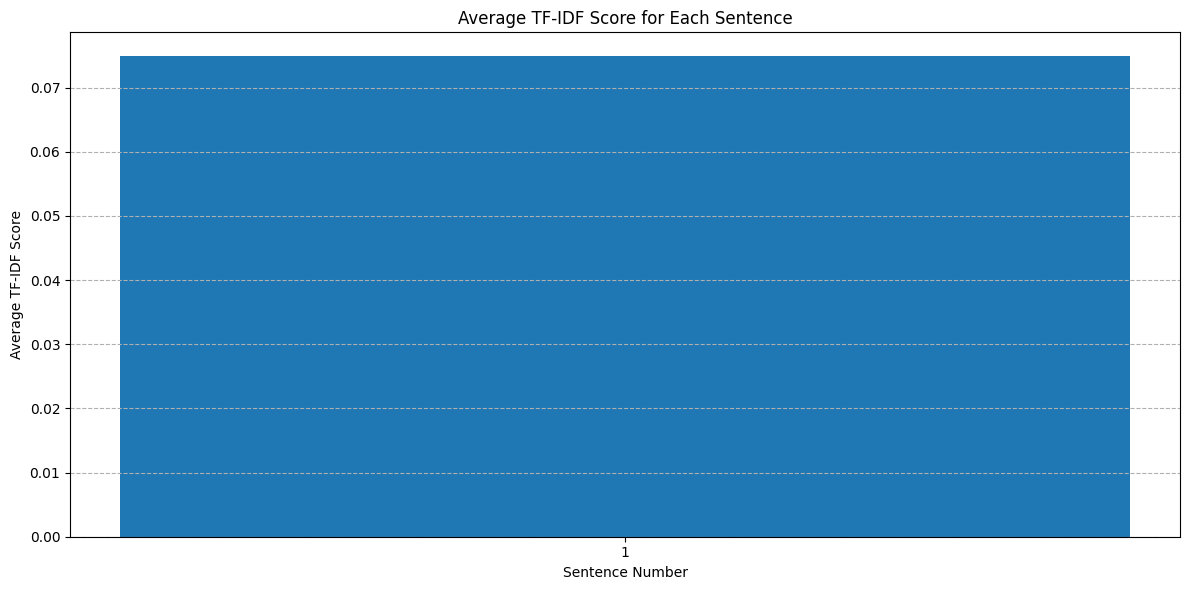

In [31]:
# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [32]:
# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [40]:
#Define Threshold 
threshold = sum(sent_scores)/len(sent_scores) if sent_scores else 0
print("Threshold (Average of sentence scores):", threshold)
#Final summary initialization 
# Calculate average TF-IDF score for each sentence
sent_scores = []

for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Threshold
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("Threshold:", threshold)

# Summary
final_summ = ""

print("\n**Summary Sentences:**")

for sentence, score in zip(sent_token, sent_scores):
    if score >= threshold:
        final_summ += " " + sentence
        print(f"- {sentence}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of sentence scores): 0.07485786679500275
Threshold: 0.07485786679500275

**Summary Sentences:**
- 
The weather has always been a quiet storyteller, shaping the rhythm of daily life in ways people often overlook.

**Final Summary:**
The weather has always been a quiet storyteller, shaping the rhythm of daily life in ways people often overlook.


In [41]:
final_summ

' \nThe weather has always been a quiet storyteller, shaping the rhythm of daily life in ways people often overlook.'